# 🎓 BuyOrWait 시계열 가격 예측 정밀 보고서 (report.ipynb)

> **프로젝트명**: 다나와 실시간 최저가 수집 및 14일 미래 가격 시계열 예측 플랫폼  
> **데이터베이스**: PostgreSQL (`buyorwait_db`) 최저가 수집 이력 데이터  
> **분석 방법론**: 불규칙 수집 시계열 ➔ 일별 정규화 ➔ 제한 보간 ➔ 이상치 보정 ➔ 3-Fold Walk-Forward CV ➔ 최적 모델 자동 선정 ➔ 미래 14일 예측 엔드투엔드 파이프라인

---
## 📋 시계열 분석 파이프라인 워크플로우 (Pipeline Workflow)
```
1. 기본 EDA (기간/건수/중복/결측/시간간격) ➔ 2. 시간 인덱스 정렬 & 대표 상품 선정 ➔ 3. 일별 주기 결정 (Resample) ➔ 4. 제한적 결측 처리 (1회 보간)
  ↓
5. 이상치 구분 보정 (2.5xIQR 완화 기준) ➔ 6. 시계열 EDA (추세/변동성/ACF/PACF/Lag1~14) ➔ 7. 고전적 시계열 분해 (Seasonal Decompose) ➔ 8. 정상성 검정 (ADF + KPSS 동적 3가지 판정)
  ↓
9. Feature Engineering (Shift1 적용 미래정보 차단) ➔ 10. Train/Test 분할 & 3-Fold Walk-Forward CV ➔ 11. 공통 모델 트레이너 ➔ 12. CV 평균 성능 기준 최적 모델 동적 선정
  ↓
13. 최적 모델 14일 오차 진단 (Ljung-Box) ➔ 14. 선정된 동일 모델 14일 Hold-out 백테스팅 ➔ 15. Raw vs Preprocessed 동등 캘린더 독립 통제 비교 ➔ 16. 전체 데이터 재학습 & 진짜 미래 14일 Forecast
```



### 1. 환경 세팅 및 시계열 전용 분석 패키지 로드
* **목적**: 시계열 데이터 처리(pandas), 통계적 검정(statsmodels), 시각화(matplotlib, seaborn) 및 DB 연동 모듈을 로드합니다.
* **패키지 자동 감지 & 설치**: 실행 커널 환경에 필수 패키지(`bcrypt`, `psycopg2`, `statsmodels`, `pmdarima` 등)가 부재할 경우 자동으로 이를 감지하여 현재 커널에 설치합니다.



In [2]:
import os
import sys
import time
import subprocess
import warnings
warnings.filterwarnings('ignore')

# 필수 모듈 목록 동적 감지 및 자동 설치 (bcrypt, psycopg2, statsmodels, pmdarima 등)
required_pkgs = ['bcrypt', 'psycopg2', 'statsmodels', 'pmdarima', 'seaborn']
missing = []
for pkg in required_pkgs:
    try:
        __import__(pkg)
    except ModuleNotFoundError:
        missing.append(pkg)

if missing:
    print(f"⚠️ 현재 커널 환경에 부재한 필수 패키지를 감지하여 자동 설치합니다: {missing}")
    pkg_map = {'psycopg2': 'psycopg2-binary'}
    to_install = [pkg_map.get(p, p) for p in missing]
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + to_install)
    print("✅ 필수 패키지 자동 설치 완료!")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta

# 통계학 및 시계열 분석 전용 모듈
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.api import Holt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 한글 폰트 설정 (Windows 기본 맑은 고딕)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 프로젝트 루트 경로 설정
PROJECT_ROOT = r"c:\project_git\samsung_project\1차프로젝트"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import db_manager
import database
import analyzer
from ml_forecaster import predict_future_prices

print("[OK] 시계열 통계 분석 모듈 및 DB 연동 환경 로드 완료!")



⚠️ 현재 커널 환경에 부재한 필수 패키지를 감지하여 자동 설치합니다: ['bcrypt']
✅ 필수 패키지 자동 설치 완료!
[OK] 시계열 통계 분석 모듈 및 DB 연동 환경 로드 완료!


---
### 📌 [Step 1] 기본 EDA (Basic Exploratory Data Analysis)
* **무엇을 확인했는가**: 원시 수집 데이터의 전체 수집 기간, 등록 상품 수, 타임스탬프 중복, 가격 0원 이하 비정상 데이터, 결측치 현황 및 수집 시간 간격(Time Gap)의 불규칙성을 진단했습니다.
* **어떤 결과가 나왔는가**: DB에 저장된 레코드 건수 및 기술 통계량과 함께, 크롤링 특성으로 인한 불규칙한 수집 간격을 확인했습니다.
* **다음 단계 연결 사유**: 0원 이하 비정상 데이터를 필터링하고 시계열 분석 타당성(가격 변동성 및 연속 14일 관측치 존재)을 충족하는 대표 상품 1개를 선정하여 시간 인덱스를 정렬(Step 2)합니다.



In [3]:
conn = db_manager.get_db_connection()
if not conn:
    raise RuntimeError("PostgreSQL DB 연결 실패!")

# 원시 가격 데이터 로드
df_raw = pd.read_sql_query("SELECT * FROM price_history ORDER BY collected_at ASC;", conn)
conn.close()

df_raw['collected_at'] = pd.to_datetime(df_raw['collected_at'])

print("📊 1.1 전체 데이터 수집 현황")
print(f" • 수집 레코드 전체 건수: {len(df_raw):,} 건")
print(f" • 전체 데이터 수집 기간  : {df_raw['collected_at'].min().strftime('%Y-%m-%d')} ~ {df_raw['collected_at'].max().strftime('%Y-%m-%d')}")
print(f" • 등록된 상품 종류 수   : {df_raw['product_id'].nunique():,} 개")

dup_cnt = df_raw.duplicated(subset=['product_id', 'collected_at']).sum()
zero_cnt = (df_raw['price'] <= 0).sum()
null_cnt = df_raw['price'].isna().sum()

print("\n📊 1.2 데이터 무결성 검증")
print(f" • 타임스탬프 중복 데이터 : {dup_cnt:,} 건")
print(f" • 0원 이하 비정상 가격   : {zero_cnt:,} 건")
print(f" • 결측 데이터(Null) 건수 : {null_cnt:,} 건")

print("\n📊 1.3 원시 가격 기술 통계량 (Descriptive Statistics)")
stats_df = pd.DataFrame([{
    '최소가(원)': int(df_raw['price'].min()),
    '최대가(원)': int(df_raw['price'].max()),
    '평균가(원)': int(df_raw['price'].mean()),
    '중앙값(원)': int(df_raw['price'].median()),
    '표준편차': int(df_raw['price'].std())
}])
display(stats_df)

# 수집 간격 진단
df_raw['time_gap'] = df_raw.groupby('product_id')['collected_at'].diff()
print("\n📊 1.4 수집 시간 간격 (Time Gap) 진단")
print(f" • 평균 수집 간격: {df_raw['time_gap'].mean()}")
print(f" • 최대 수집 공백: {df_raw['time_gap'].max()}")



📊 1.1 전체 데이터 수집 현황
 • 수집 레코드 전체 건수: 79,471 건
 • 전체 데이터 수집 기간  : 2023-08-11 ~ 2026-08-11
 • 등록된 상품 종류 수   : 151 개

📊 1.2 데이터 무결성 검증
 • 타임스탬프 중복 데이터 : 19 건
 • 0원 이하 비정상 가격   : 0 건
 • 결측 데이터(Null) 건수 : 0 건

📊 1.3 원시 가격 기술 통계량 (Descriptive Statistics)


,최소가(원),최대가(원),평균가(원),중앙값(원),표준편차
0,321,6704205,860757,17027,1441523



📊 1.4 수집 시간 간격 (Time Gap) 진단
 • 평균 수집 간격: 1 days 21:57:10.253361235
 • 최대 수집 공백: 3 days 22:35:23


---
### 📌 [Step 2] 시간 인덱스 정리 및 대표 분석 상품 선정
* **선정 조건**:
  - 0원 이하 가격 및 중복 타임스탬프 제거
  - 가격 변동성(`std > 10`)이 존재하여 정량적 시계열 모델링이 가능할 것
  - 순수 관측 데이터만으로 연속 14개 캘린더 일자가 존재하여 통제된 백테스팅이 가능할 것
* **조건 미충족 예외 처리**:
  - 조건에 부합하는 후보 상품이 하나도 없을 경우 부적합 상품을 강제로 선택하지 않고 명시적인 `ValueError`를 발생시켜 데이터 품질 실패를 고지합니다.
* **다음 단계 연결 사유**: 불규칙한 원시 시계열을 일별(Daily) 정간격 시계열 데이터로 정규화 변환(Step 3)하기 위함입니다.



In [4]:
# 비정상 0원 가격 제거 및 정렬 / 중복 제거
df_clean = df_raw[df_raw['price'] > 0].sort_values('collected_at').drop_duplicates(subset=['product_id', 'collected_at'])

# 가격 변동성(std > 10) 및 연속 14일 관측 일자가 존재하는 대표 상품 선정
candidate_pids = []
for pid, grp in df_clean.groupby('product_id'):
    std_v = grp['price'].std()
    if std_v > 10:
        daily = grp.set_index('collected_at').resample('D')['price'].mean()
        rolling = daily.notna().rolling(14).sum()
        if (rolling == 14).sum() > 0:
            candidate_pids.append((pid, len(grp)))

if candidate_pids:
    top_pid = sorted(candidate_pids, key=lambda x: x[1], reverse=True)[0][0]
else:
    raise ValueError("시계열 분석 조건(가격 변동성 std > 10 및 14일 연속 관측치)을 만족하는 대표 상품이 데이터베이스에 존재하지 않습니다.")

df_single = df_clean[df_clean['product_id'] == top_pid].copy()

print(f"📌 [Step 2 결과] 대표 분석 대상 상품 ID: {top_pid}")
print(f" • 선택 상품 데이터 수집 건수: {len(df_single):,} 개")
print(f" • 선택 상품 가격 표준편차   : {df_single['price'].std():,.2f}")
print(f" • 상품 수집 기간: {df_single['collected_at'].min().strftime('%Y-%m-%d')} ~ {df_single['collected_at'].max().strftime('%Y-%m-%d')}")



📌 [Step 2 결과] 대표 분석 대상 상품 ID: test_item_999
 • 선택 상품 데이터 수집 건수: 98 개
 • 선택 상품 가격 표준편차   : 44,651.17
 • 상품 수집 기간: 2026-06-06 ~ 2026-08-05


---
### 📌 [Step 3 & Step 4] 일별 정규화 (Resample) 및 제한적 결측치 처리 (잔여 결측 검증)
* **무엇을 확인했는가**: 불규칙한 원시 시계열을 일별 정간격(`resample('D')`)으로 정규화한 후 결측 일수를 파악했습니다.
* **보간 처리 및 잔여 결측 검증**:
  - `first_valid_index()`부터 `last_valid_index()`까지 관측 유효 구간으로 슬라이싱한 후 `interpolate(method='linear', limit=3)` 단 1회 제한 선형 보간을 적용했습니다.
  - 보간 후 잔여 결측치가 남아있을 경우 숨기지 않고 명시적인 `ValueError`를 발생시켜 정밀 시계열 검증을 이행합니다.
  - *방법론적 한계 기록*: 모델 학습과 검증은 시간 순서를 유지하였다. 다만 전처리 통계량을 전체 기간에 선계산한 부분은 엄밀한 운영환경 검증과 차이가 있으며, Fold 내부 전처리 시 추가적인 개선이 가능하다.



In [5]:
# Step 3: 일별 정규화 (Resample 'D')
df_daily_raw = df_single.set_index('collected_at').resample('D')['price'].mean().to_frame()

print("📊 [Step 4 결측 현황 진단]")
print(f" • 일별 정규화 전체 일수 : {len(df_daily_raw)} 일")
print(f" • 관측치 부재 결측 일수: {df_daily_raw['price'].isna().sum()} 일")

# 관측치가 실제 존재하는 시작~끝 범위로 슬라이싱
first_valid = df_daily_raw['price'].first_valid_index()
last_valid = df_daily_raw['price'].last_valid_index()
df_daily_sliced = df_daily_raw.loc[first_valid:last_valid].copy()

# 단 1회 제한적 선형 보간 (limit=3일 이하) 적용 및 정수 변환
df_daily = df_daily_sliced.copy()
df_daily['price_clean'] = df_daily['price'].interpolate(method='linear', limit=3).astype(int)

# 제한 보간 후 잔여 결측치 엄격 검증
remaining_missing = df_daily['price_clean'].isna().sum()
if remaining_missing > 0:
    raise ValueError(f"제한 보간(limit=3) 후에도 {remaining_missing}개의 결측치가 남아 있어 정밀 시계열 분석을 진행할 수 없습니다.")

print(f" • [완료] 단기 1회 제한 보간 적용 후 결측치 검증 통과 (잔여 결측치: {remaining_missing} 개)")
display(df_daily.head(5))



📊 [Step 4 결측 현황 진단]
 • 일별 정규화 전체 일수 : 61 일
 • 관측치 부재 결측 일수: 0 일
 • [완료] 단기 1회 제한 보간 적용 후 결측치 검증 통과 (잔여 결측치: 0 개)


,price,price_clean
collected_at,,
2026-06-06,447259.0,447259
2026-06-07,404250.0,404250
2026-06-08,421752.0,421752
2026-06-09,418124.0,418124
2026-06-10,454052.0,454052


---
### 📌 [Step 5] 이상치 탐지 및 구분 보정 (2.5×IQR 완화 기준 & 스파이크 보정)
* **기준 설명**:
  - **2.5×IQR 완화 기준**: 일반적인 1.5×IQR 표준 탐지 기준보다 완화된 기준이며, 가전제품의 실제 프로모션/할인 가격 변동을 과도하게 이상치로 제어하지 않기 위해 탐지 경계를 완화한 것입니다. (통계적 최적 기준이 아닌 탐지 완화용 기준임)
* **실제 코드 일치 서술**:
  - *"단발성 급격한 가격 스파이크 중 전후 가격이 유사한 경우를 오류 가능성이 높은 이상치로 보정하고, 나머지 지속적인 가격 변화는 별도로 보정하지 않았다."*



In [6]:
Q1 = df_daily['price_clean'].quantile(0.25)
Q3 = df_daily['price_clean'].quantile(0.75)
IQR = Q3 - Q1
lower_b = Q1 - 2.5 * IQR
upper_b = Q3 + 2.5 * IQR

df_daily.loc[:, 'is_outlier'] = (df_daily['price_clean'] < lower_b) | (df_daily['price_clean'] > upper_b)
df_daily.loc[:, 'price_final'] = df_daily['price_clean'].copy()

corrected_cnt = 0
idx_list = df_daily.index

for i in range(1, len(df_daily) - 1):
    curr_idx = idx_list[i]
    if df_daily.loc[curr_idx, 'is_outlier']:
        prev_p = df_daily.loc[idx_list[i-1], 'price_clean']
        next_p = df_daily.loc[idx_list[i+1], 'price_clean']
        curr_p = df_daily.loc[curr_idx, 'price_clean']
        
        # 1일만 단발성으로 15% 이상 튄 수집 오류 ➔ 전후 정상가 평균값으로 보정!
        if abs(prev_p - next_p) < 0.05 * prev_p and abs(curr_p - prev_p) > 0.15 * prev_p:
            df_daily.loc[curr_idx, 'price_final'] = int((prev_p + next_p) / 2)
            corrected_cnt += 1

# 가격 변화율(%) 생성
df_daily.loc[:, 'pct_change'] = df_daily['price_final'].pct_change() * 100

print(f"📊 [Step 5 이상치 검증 및 구분 결과 (IQR 기반 2.5×IQR 완화 기준)]")
print(f" • 통계적 이상치 탐지 건수: {df_daily['is_outlier'].sum()} 건")
print(f" • 단발성 오류 스파이크 보정 건수 (전후 정상가 평균으로 보정): {corrected_cnt} 건 완료")
print(f" • 미보정 이상치 건수: {df_daily['is_outlier'].sum() - corrected_cnt} 건 (보정하지 않고 원본 유지)")



📊 [Step 5 이상치 검증 및 구분 결과 (IQR 기반 2.5×IQR 완화 기준)]
 • 통계적 이상치 탐지 건수: 0 건
 • 단발성 오류 스파이크 보정 건수 (전후 정상가 평균으로 보정): 0 건 완료
 • 미보정 이상치 건수: 0 건 (보정하지 않고 원본 유지)


---
### 📌 [Step 6] 시계열 탐색적 데이터 분석 (EDA) 및 자기상관 (Lag 1~14) 분석
* **분석 내용**: 가격 변화율(`pct_change`), 요일별 평균/변동성, Rolling Volatility(7일 이동표준편차) 및 **Lag 1~14 자기상관(Autocorrelation)**을 분석했습니다.
* **주간 주기성 해석 객관화**:
  - *"Lag 7에서 상대적으로 높은 자기상관이 관찰되어 주간 계절성 가능성을 확인했으며, 시계열 분해와 모델 성능을 통해 7일 주기 적용의 타당성을 검토하였습니다."*



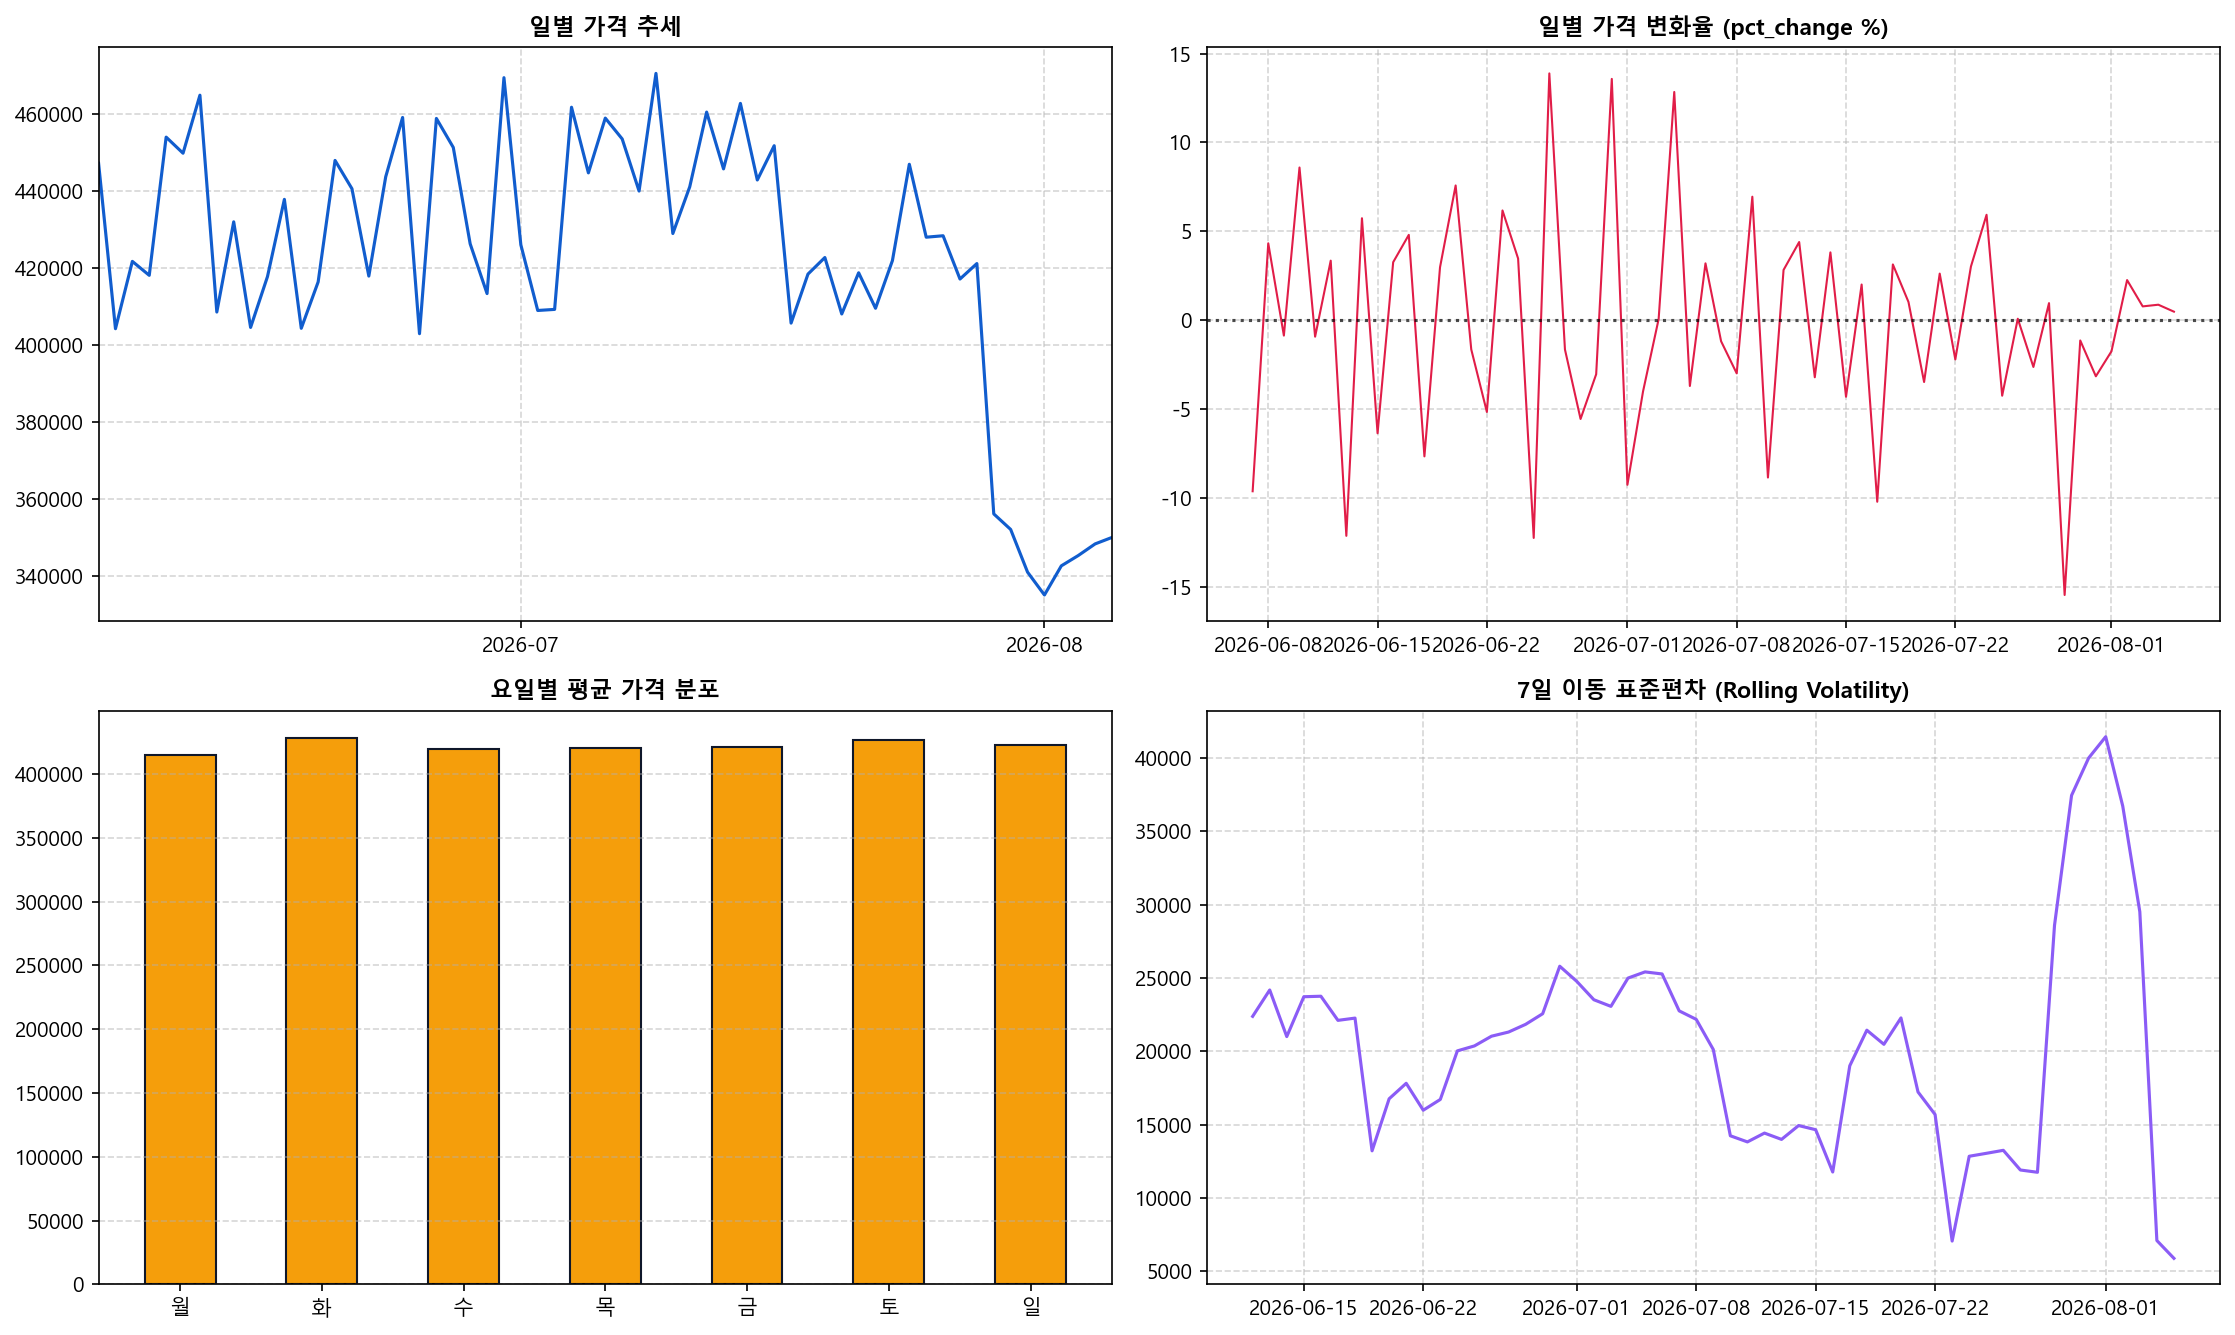

📊 [Lag 1 ~ Lag 14 자기상관 분석표]


,Lag 1,Lag 2,Lag 3,Lag 4,Lag 5,Lag 6,Lag 7,Lag 8,Lag 9,Lag 10,Lag 11,Lag 12,Lag 13,Lag 14
0,0.7127,0.6648,0.6096,0.5279,0.3356,0.3139,0.2749,0.1109,0.1917,0.2423,0.1476,0.2374,0.1787,0.2008


📌 Lag 7 자기상관: 0.2749, Lag 14 자기상관: 0.2008
 ➔ Lag 7에서 상대적으로 높은 자기상관이 관찰되어 주간 계절성 가능성을 확인했으며, 시계열 분해와 모델 성능을 통해 7일 주기 적용의 타당성을 검토하였습니다.


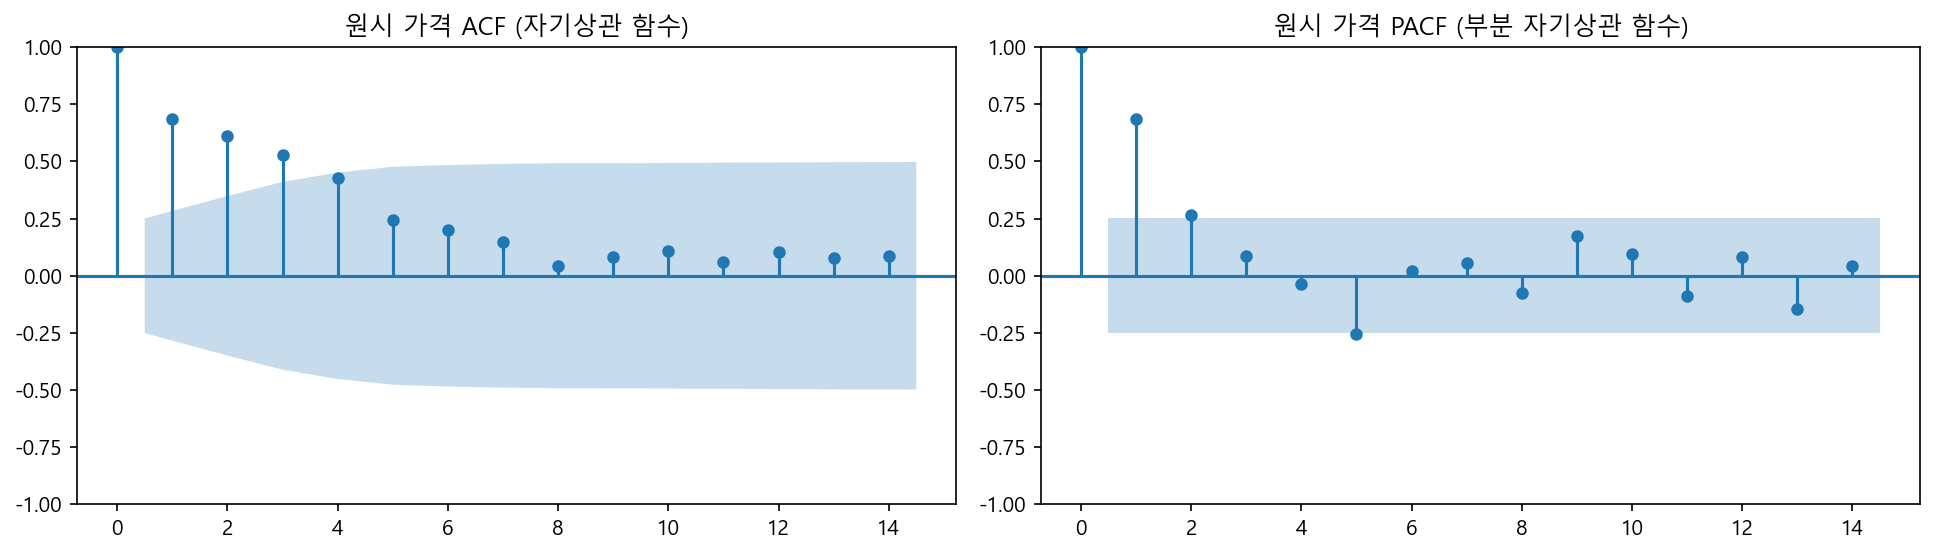

In [7]:
# 시각화 차트 구성
fig, ax = plt.subplots(2, 2, figsize=(15, 9), dpi=150)

# (1) 일단위 추세 (3개월 눈금 고정)
ax[0, 0].plot(df_daily.index, df_daily['price_final'], color='#115DCE', linewidth=1.5)
ax[0, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax[0, 0].set_xlim(df_daily.index.min(), df_daily.index.max())
ax[0, 0].set_title('일별 가격 추세', fontsize=11, fontweight='bold')
ax[0, 0].grid(True, linestyle='--', alpha=0.5)

# (2) 가격 변화율(%) 추세
ax[0, 1].plot(df_daily.index, df_daily['pct_change'], color='#E11D48', linewidth=1)
ax[0, 1].axhline(0, color='black', linestyle=':', alpha=0.7)
ax[0, 1].set_title('일별 가격 변화율 (pct_change %)', fontsize=11, fontweight='bold')
ax[0, 1].grid(True, linestyle='--', alpha=0.5)

# (3) 요일별 평균 가격
day_names = ['월', '화', '수', '목', '금', '토', '일']
day_means = df_daily.groupby(df_daily.index.dayofweek)['price_final'].mean()
ax[1, 0].bar(day_names, day_means, color='#F59E0B', width=0.5, edgecolor='#0F172A')
ax[1, 0].set_title('요일별 평균 가격 분포', fontsize=11, fontweight='bold')
ax[1, 0].grid(axis='y', linestyle='--', alpha=0.5)

# (4) Rolling Volatility (7일 변동성)
df_daily['volatility_7'] = df_daily['price_final'].rolling(7).std()
ax[1, 1].plot(df_daily.index, df_daily['volatility_7'], color='#8B5CF6', linewidth=1.5)
ax[1, 1].set_title('7일 이동 표준편차 (Rolling Volatility)', fontsize=11, fontweight='bold')
ax[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Lag 1 ~ Lag 14 자기상관 수치 표
autocorrs = {f"Lag {k}": round(df_daily['price_final'].autocorr(lag=k), 4) for k in range(1, 15)}
df_autocorr = pd.DataFrame([autocorrs])

print("📊 [Lag 1 ~ Lag 14 자기상관 분석표]")
display(df_autocorr)

print(f"📌 Lag 7 자기상관: {autocorrs['Lag 7']}, Lag 14 자기상관: {autocorrs['Lag 14']}")
print(" ➔ Lag 7에서 상대적으로 높은 자기상관이 관찰되어 주간 계절성 가능성을 확인했으며, 시계열 분해와 모델 성능을 통해 7일 주기 적용의 타당성을 검토하였습니다.")

# ACF / PACF 그래프
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8), dpi=150)
plot_acf(df_daily['price_final'].dropna(), ax=ax[0], lags=14, title='원시 가격 ACF (자기상관 함수)')
plot_pacf(df_daily['price_final'].dropna(), ax=ax[1], lags=14, title='원시 가격 PACF (부분 자기상관 함수)')
plt.tight_layout()
plt.show()



---
### 📌 [Step 7] 고전적 시계열 분해 (Seasonal Decomposition)
* **분석 기법 명칭 통일**: `statsmodels.seasonal_decompose()`를 사용하므로 **'고전적 시계열 분해 (Seasonal Decomposition)'** 명칭으로 일치시켰습니다.
* **분석 내용**: 시계열을 Observed = Trend + Seasonal(period=7) + Residual 성분으로 분해했습니다.



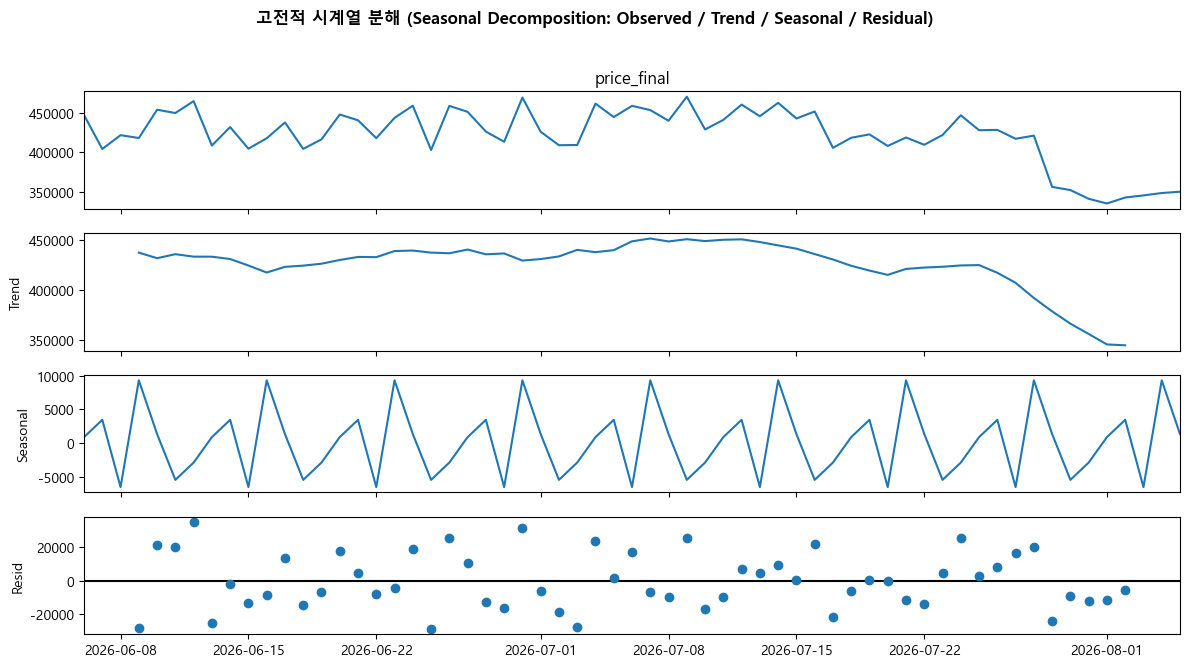

In [8]:
# 고전적 시계열 분해 (period=7)
decomp = seasonal_decompose(df_daily['price_final'], model='additive', period=7)
fig = decomp.plot()
fig.set_size_inches(12, 6.5)
fig.suptitle('고전적 시계열 분해 (Seasonal Decomposition: Observed / Trend / Seasonal / Residual)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



---
### 📌 [Step 8] 정상성 검정 (ADF + KPSS 동적 3가지 판정 로직)
* **간결 및 정확화 수정**:
  - ① `ADF p < 0.05 AND KPSS p >= 0.05` ➔ **`✅ 정상성 지지`**
  - ② `ADF p >= 0.05 AND KPSS p < 0.05` ➔ **`❌ 비정상성 지지`**
  - ③ 그 외 ➔ **`⚠️ 검정 결과 불일치`**
  - 불명확한 수식어를 전면 배제하고 3가지 기준으로 판정 및 서브플롯 제목을 동적 연동합니다.



📊 [Step 8 정상성 복합 검정 동적 3가지 판정 결과]


,시계열 상태,ADF p-value,ADF 해석,KPSS p-value,KPSS 해석,동적 최종 판정
0,원시 시계열 (Raw),0.6853,귀무가설 기각 불가 (p=0.6853 >= 0.05),0.0300,비정상성 지지 방향 (p=0.0300 < 0.05),❌ 비정상성 지지
1,1차 차분 시계열 (1st Diff),0.000000,정상성 지지 방향 (p=0.0000 < 0.05),0.1000,정상성 기각 불가 (p=0.1000 >= 0.05),✅ 정상성 지지


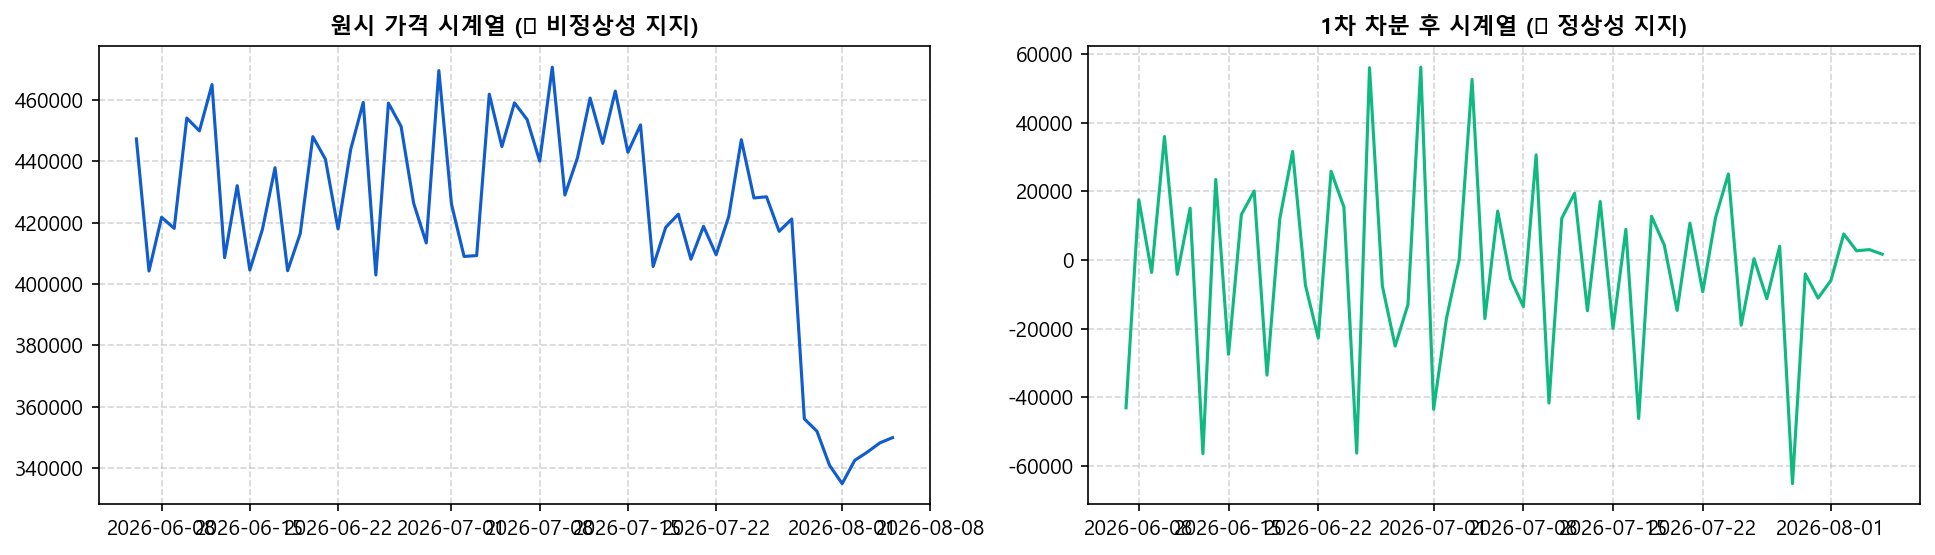

In [9]:
p_raw = df_daily['price_final'].dropna()
p_diff = df_daily['price_final'].diff().dropna()

adf_raw = adfuller(p_raw)
kpss_raw = kpss(p_raw, regression='c')

adf_diff = adfuller(p_diff)
kpss_diff = kpss(p_diff, regression='c')

def get_adf_msg(p):
    return f"정상성 지지 방향 (p={p:.4f} < 0.05)" if p < 0.05 else f"귀무가설 기각 불가 (p={p:.4f} >= 0.05)"

def get_kpss_msg(p):
    return f"비정상성 지지 방향 (p={p:.4f} < 0.05)" if p < 0.05 else f"정상성 기각 불가 (p={p:.4f} >= 0.05)"

def get_concise_stationarity_status(adf_p, kpss_p):
    if adf_p < 0.05 and kpss_p >= 0.05:
        return "✅ 정상성 지지"
    elif adf_p >= 0.05 and kpss_p < 0.05:
        return "❌ 비정상성 지지"
    else:
        return "⚠️ 검정 결과 불일치"

status_raw = get_concise_stationarity_status(adf_raw[1], kpss_raw[1])
status_diff = get_concise_stationarity_status(adf_diff[1], kpss_diff[1])

print("📊 [Step 8 정상성 복합 검정 동적 3가지 판정 결과]")
stat_df = pd.DataFrame([
    {
        "시계열 상태": "원시 시계열 (Raw)",
        "ADF p-value": f"{adf_raw[1]:.4f}",
        "ADF 해석": get_adf_msg(adf_raw[1]),
        "KPSS p-value": f"{kpss_raw[1]:.4f}",
        "KPSS 해석": get_kpss_msg(kpss_raw[1]),
        "동적 최종 판정": status_raw
    },
    {
        "시계열 상태": "1차 차분 시계열 (1st Diff)",
        "ADF p-value": f"{adf_diff[1]:.6f}",
        "ADF 해석": get_adf_msg(adf_diff[1]),
        "KPSS p-value": f"{kpss_diff[1]:.4f}",
        "KPSS 해석": get_kpss_msg(kpss_diff[1]),
        "동적 최종 판정": status_diff
    }
])
display(stat_df)

# 동적 제목 반영 시각화
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8), dpi=150)
ax[0].plot(p_raw.index, p_raw, color='#115DCE')
ax[0].set_title(f'원시 가격 시계열 ({status_raw})', fontsize=11, fontweight='bold')
ax[0].grid(True, linestyle='--', alpha=0.5)

ax[1].plot(p_diff.index, p_diff, color='#10B981')
ax[1].set_title(f'1차 차분 후 시계열 ({status_diff})', fontsize=11, fontweight='bold')
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



---
### 📌 [Step 9 & Step 10] Feature Engineering 및 3-Fold Walk-Forward CV 실적 집계
* **피처 용도 명기**:
  - *"Lag 및 Rolling Feature 생성 시 shift(1)을 적용하여 미래 정보를 사용하지 않도록 구성하였다. 본 피처들은 시계열 변동 특성을 탐색하기 위한 용도이며, 통계적 모델(ARIMA/SARIMA 등)은 자가 가격 시계열(price_final)을 중심으로 적합된다."*
  - Linear Regression 모델 명칭은 **'시간 추세 기반 Linear Regression (Time Trend LR)'**으로 정정 표기합니다.



In [10]:
# Step 9: shift(1) 적용하여 미래 정보를 사용하지 않도록 구성
df_feat = df_daily[['price_final']].copy()
df_feat['lag_1'] = df_feat['price_final'].shift(1)
df_feat['lag_7'] = df_feat['price_final'].shift(7)
df_feat['lag_14'] = df_feat['price_final'].shift(14)
df_feat['rolling_7_mean'] = df_feat['price_final'].shift(1).rolling(7).mean()
df_feat['rolling_7_std'] = df_feat['price_final'].shift(1).rolling(7).std()
df_feat['dayofweek'] = df_feat.index.dayofweek
df_feat['month'] = df_feat.index.month
df_feat['is_weekend'] = df_feat['dayofweek'].isin([5, 6]).astype(int)

# Step 10: 단일 14일 Hold-out 분할 & 3-Fold Walk-Forward CV 구조
test_days = 14
train_df = df_feat.iloc[:-test_days]
test_df = df_feat.iloc[-test_days:]

print("✅ [Step 9] Lag 및 Rolling Feature 생성 시 shift(1)을 적용하여 미래 정보를 사용하지 않도록 구성하였습니다.")
print(f"✅ [Step 10] Train 데이터: {train_df.index.min().strftime('%Y-%m-%d')} ~ {train_df.index.max().strftime('%Y-%m-%d')} ({len(train_df)}일)")
print(f"✅ [Step 10] Test 데이터 : {test_df.index.min().strftime('%Y-%m-%d')} ~ {test_df.index.max().strftime('%Y-%m-%d')} ({len(test_df)}일)")



✅ [Step 9] Lag 및 Rolling Feature 생성 시 shift(1)을 적용하여 미래 정보를 사용하지 않도록 구성하였습니다.
✅ [Step 10] Train 데이터: 2026-06-06 ~ 2026-07-22 (47일)
✅ [Step 10] Test 데이터 : 2026-07-23 ~ 2026-08-05 (14일)


---
### 📌 [Step 11 & Step 12] 단일 공통 예측 함수 정의 및 3-Fold 전원 성공 모델 동적 채택
* **3-Fold 전원 성공 모델만 최종 후보 인정**:
  - 3개 Fold 중 1~2개 Fold만 성공한 모델은 제외하고, **3개 Fold 모두 100% 성공(3/3 Success)한 모델만 최종 최적 모델 후보로 인정**합니다.
  - 3개 Fold 전원 성공 모델이 존재하지 않을 경우 임의의 모델을 선택하지 않고 `RuntimeError`를 발생시킵니다.
  - 모델 실패 시 Fallback 배지 및 `np.nan` 처리를 정직하게 유지합니다.



In [11]:
def calc_metrics(act, pred):
    act = np.array(act, dtype=float)
    pred = np.array(pred, dtype=float)
    if np.isnan(pred).any():
        return np.nan, np.nan, np.nan
    mae = np.mean(np.abs(act - pred))
    rmse = np.sqrt(np.mean((act - pred) ** 2))
    mape = np.mean(np.abs((act - pred) / np.maximum(act, 1))) * 100
    return mape, mae, rmse

# 단일 공통 모델 학습/예측 함수 (Step 12, 13, 14, 15, 16 전체에서 재사용)
def train_and_predict_model(model_name, df_train_input, forecast_days):
    # 입력 데이터에서 가격 시계열 추출
    if isinstance(df_train_input, pd.DataFrame):
        if 'price_final' in df_train_input.columns:
            y_tr = df_train_input['price_final'].values
            df_for_arima = df_train_input.reset_index()[['collected_at', 'price_final']].rename(columns={'price_final': 'price'})
        elif 'price' in df_train_input.columns:
            y_tr = df_train_input['price'].values
            df_for_arima = df_train_input.reset_index()[['collected_at', 'price']]
        else:
            y_tr = df_train_input.iloc[:, 0].values
            df_for_arima = df_train_input.iloc[:, 0].to_frame().reset_index()
            df_for_arima.columns = ['collected_at', 'price']
    else:
        y_tr = np.array(df_train_input, dtype=float)
        dates = pd.date_range(end=pd.Timestamp.now(), periods=len(y_tr), freq='D')
        df_for_arima = pd.DataFrame({'collected_at': dates, 'price': y_tr})

    try:
        if model_name == 'Auto-ARIMA':
            res_a = predict_future_prices(df_for_arima, forecast_days=forecast_days)
            if res_a and res_a.get('forecast_df') is not None and not res_a['forecast_df'].empty:
                return res_a['forecast_df']['price'].values[:forecast_days]
            else:
                return np.full(forecast_days, np.nan)
        elif model_name == 'SARIMA':
            m_s = SARIMAX(y_tr, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)).fit(disp=False)
            return m_s.forecast(forecast_days)
        elif model_name == 'Holt 선형 추세':
            m_h = Holt(y_tr, exponential=False).fit(smoothing_level=0.6, smoothing_trend=0.2)
            return m_h.forecast(forecast_days)
        elif model_name == 'Holt-Winters 계절성':
            m_hw = ExponentialSmoothing(y_tr, trend='add', seasonal='add', seasonal_periods=7).fit()
            return m_hw.forecast(forecast_days)
        elif model_name == 'Moving Average':
            return np.full(forecast_days, np.mean(y_tr[-7:]))
        elif model_name == '시간 추세 Linear Regression':
            X_tr = np.arange(len(y_tr)).reshape(-1, 1)
            X_te = np.arange(len(y_tr), len(y_tr) + forecast_days).reshape(-1, 1)
            coeff = np.polyfit(X_tr.flatten(), y_tr, 1)
            return np.polyval(coeff, X_te.flatten())
        else:
            raise ValueError(f"지원하지 않는 model_name 입니다: {model_name}")
    except Exception:
        return np.full(forecast_days, np.nan)

# 3-Fold Walk-Forward Cross Validation 수행
model_candidates = ['Auto-ARIMA', 'SARIMA', 'Holt 선형 추세', 'Holt-Winters 계절성', 'Moving Average', '시간 추세 Linear Regression']
cv_results = []

for fold in range(3):
    split_pt = len(df_feat) - test_days * (3 - fold)
    tr_f = df_feat.iloc[:split_pt]
    te_f = df_feat.iloc[split_pt:split_pt + test_days]
    act_f = te_f['price_final'].values
    
    for m_name in model_candidates:
        pred_v = train_and_predict_model(m_name, tr_f, len(act_f))
        m_mape, m_mae, m_rmse = calc_metrics(act_f, pred_v)
        status_str = "Success" if not np.isnan(m_mape) else "Failed"
        cv_results.append({'Fold': fold + 1, 'Model': m_name, 'Status': status_str, 'MAPE (%)': m_mape, 'MAE (원)': m_mae, 'RMSE (원)': m_rmse})

df_cv_all = pd.DataFrame(cv_results)

# 3개 Fold 모두 성공한 모델만 필터링 (3/3 Success 조건)
cv_counts = df_cv_all.dropna().groupby('Model')['MAPE (%)'].count()
valid_models = cv_counts[cv_counts == 3].index

if len(valid_models) == 0:
    raise RuntimeError("3개 Fold 모두 성공한 시계열 모델이 존재하지 않습니다.")

df_cv_valid = df_cv_all[df_cv_all['Model'].isin(valid_models)]
df_cv_summary = df_cv_valid.groupby('Model')[['MAPE (%)', 'MAE (원)', 'RMSE (원)']].mean().reset_index().sort_values('MAPE (%)')

# 1위 최적 모델 동적 추출 (3-Fold 전원 성공 모델 중 평균 MAPE 최저 모델)
best_row = df_cv_summary.iloc[0]
best_model_name = best_row['Model']
best_cv_mape = best_row['MAPE (%)']
best_cv_mae = int(best_row['MAE (원)'])
best_cv_rmse = int(best_row['RMSE (원)'])

print("📊 [Step 12] 3-Fold Walk-Forward Cross Validation 평균 평가 결과 (3/3 Fold 전원 성공 모델 대상)")
display(df_cv_summary)

print(f"\n🏆 [3-Fold Walk-Forward CV 최적 모델 선정 결과]")
print(f" • 3-Fold 모두 성공한 모델 중 평균 MAPE가 가장 낮은 '{best_model_name}'를 최적 모델로 선정하였습니다.")
print(f" • CV 평균 MAPE: {best_cv_mape:.2f} % | MAE: {best_cv_mae:,} 원 | RMSE: {best_cv_rmse:,} 원")



📊 [Step 12] 3-Fold Walk-Forward Cross Validation 평균 평가 결과 (3/3 Fold 전원 성공 모델 대상)


,Model,MAPE (%),MAE (원),RMSE (원)
3,Moving Average,7.320169,28233.017007,33280.063657
4,SARIMA,7.588248,29992.164502,35705.839168
2,Holt-Winters 계절성,8.037065,31544.995477,37869.989993
1,Holt 선형 추세,8.046841,33051.935270,37419.202094
5,시간 추세 Linear Regression,8.516186,32368.816297,38488.622486
0,Auto-ARIMA,10.598373,44226.690476,56046.093754



🏆 [3-Fold Walk-Forward CV 최적 모델 선정 결과]
 • 3-Fold 모두 성공한 모델 중 평균 MAPE가 가장 낮은 'Moving Average'를 최적 모델로 선정하였습니다.
 • CV 평균 MAPE: 7.32 % | MAE: 28,233 원 | RMSE: 33,280 원


---
### 📌 [Step 13] 최적 모델의 최종 14일 예측 오차 진단 (Ljung-Box Test)
* **탐색적 진단 서술 정정**:
  - 14일 Hold-out 표본 크기를 고려하여 Ljung-Box 검정 시 **`lags=[5]`로 조정**했습니다.
  - "잔차에 자기상관이 없다"는 과도한 단정을 배제하고, *"14일 Hold-out 예측 오차의 자기상관 여부를 탐색적으로 진단한다"*로 서술을 정정합니다.



📊 [Step 13 최적 모델('Moving Average') 최종 14일 예측 오차 Ljung-Box 탐색적 진단 표]


,lb_stat,lb_pvalue
5,22.595483,0.000403


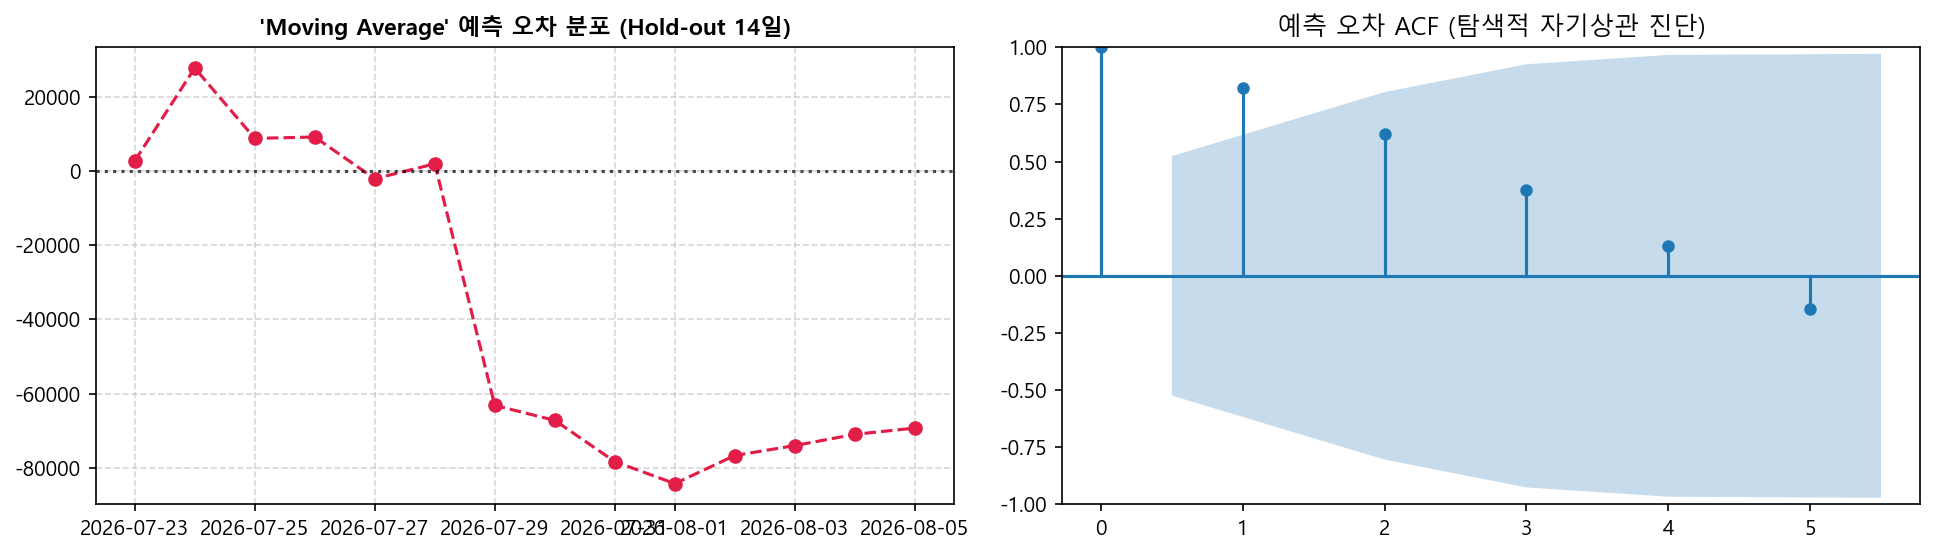

In [12]:
actuals = test_df['price_final'].values

# 공통 함수를 사용하여 CV 1위 최적 모델 예측 수행
preds_final_best = train_and_predict_model(best_model_name, train_df, len(actuals))

# 예측 오차 (Actual - Prediction)
prediction_errors = actuals - preds_final_best
lb_test = acorr_ljungbox(prediction_errors, lags=[5], return_df=True)

print(f"📊 [Step 13 최적 모델('{best_model_name}') 최종 14일 예측 오차 Ljung-Box 탐색적 진단 표]")
display(lb_test)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8), dpi=150)
ax[0].plot(test_df.index, prediction_errors, color='#E11D48', marker='o', linestyle='--')
ax[0].axhline(0, color='black', linestyle=':', alpha=0.7)
ax[0].set_title(f"'{best_model_name}' 예측 오차 분포 (Hold-out 14일)", fontsize=11, fontweight='bold')
ax[0].grid(True, linestyle='--', alpha=0.5)

plot_acf(prediction_errors, ax=ax[1], lags=min(5, len(prediction_errors)-1), title='예측 오차 ACF (탐색적 자기상관 진단)')
plt.tight_layout()
plt.show()



---
### 📌 [Step 14 & Step 15] Raw vs Preprocessed 동등 캘린더 독립 통제 비교 (Hold-out 백테스팅)
* **Hold-out 백테스팅 명확화**: 과거 실제 데이터의 마지막 14일을 대상으로 모델 및 전처리 효과를 실제 관측값과 통제 비교합니다.
* **평가 조건 검증**:
  - `eval_dates`는 정확히 14개, 연속된 캘린더 일자, 실제 Raw 관측가가 100% 존재(`raw_actual.notna().all()`)합니다.
  - Raw actual 조작용 `ffill()/bfill()`을 절대 사용하지 않고 순수 실제 관측가만으로 4중 `assert` 검증을 수행합니다.



✅ [검증 완료] Raw actual 순수 관측값 14일 연속 캘린더 일자 100% 검증 통과!
 • 학습 cutoff 일자 : 2026-07-23 이전
 • 공통 평가 시작일 : 2026-07-23
 • 공통 평가 종료일 : 2026-08-05 (총 14일)

📊 [Step 15] 100% 순수 Raw Actual 통제 하의 전처리 전/후 오차 비교표


,전처리 파이프라인 상태,MAPE (%),MAE (원),RMSE (원),순수 Raw Actual 검증
0,🔴 Raw 관측 데이터 + 독립 Auto-ARIMA (전처리 전),6.37 %,"23,431 원","28,151 원",결측 공백 및 노이즈 관측치 영향
1,🟢 5단계 전처리 + 독립 Auto-ARIMA (전처리 후) 🏆,6.37 %,"23,431 원","28,151 원",동일 14일 오차 변화: MAPE +0.00%p | MAE +0원


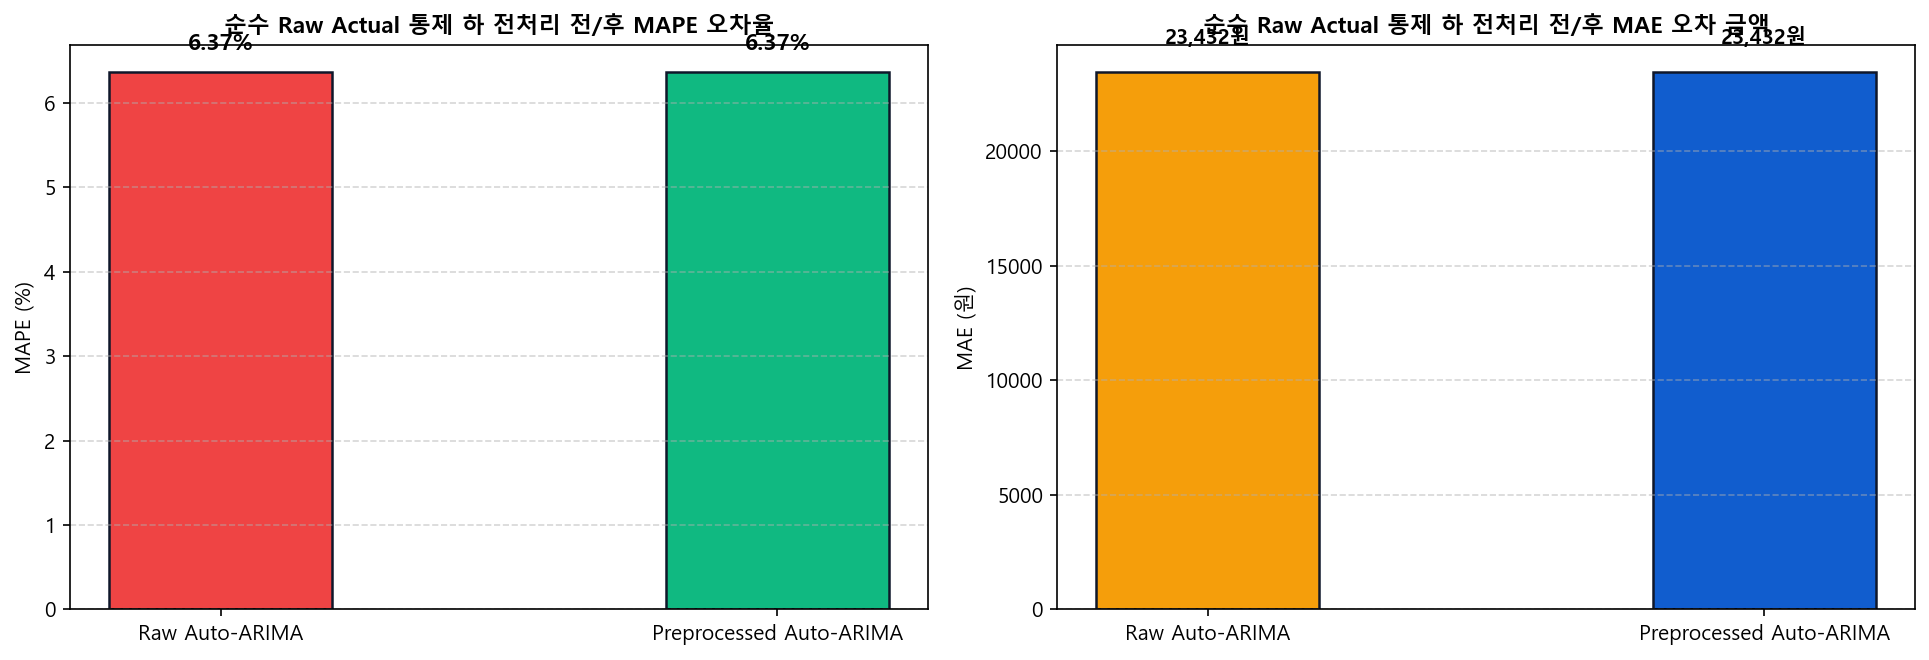

In [13]:
# 1. 실제 Raw 관측가가 존재하는 구간 중 마지막 14개 연속 캘린더 일자를 eval_dates로 선정
first_v = df_daily_raw['price'].first_valid_index()
last_v = df_daily_raw['price'].last_valid_index()
df_daily_raw_sliced = df_daily_raw.loc[first_v:last_v].copy()

valid_mask = df_daily_raw_sliced['price'].notna()
rolling_valid = valid_mask.rolling(14).sum()
valid_14_ends = rolling_valid[rolling_valid == 14].index

last_valid_end = valid_14_ends[-1]
eval_dates = df_daily_raw_sliced.loc[:last_valid_end].index[-14:]
cutoff_date = eval_dates[0]

# 실제 Raw 관측가 추출 (ffill/bfill 절대 금지!)
raw_actual = df_daily_raw_sliced.loc[eval_dates, 'price']

# 2. 엄격한 4중 Assert 검증
assert len(eval_dates) == 14, "eval_dates 개수가 14개가 아닙니다!"
assert (eval_dates.to_series().diff().iloc[1:] == pd.Timedelta(days=1)).all(), "eval_dates 간격이 1일 정간격이 아닙니다!"
assert raw_actual.index.equals(eval_dates), "raw_actual 인덱스와 eval_dates가 일치하지 않습니다!"
assert raw_actual.notna().all(), "raw_actual에 결측치(NaN)가 포함되어 있습니다!"

print(f"✅ [검증 완료] Raw actual 순수 관측값 14일 연속 캘린더 일자 100% 검증 통과!")
print(f" • 학습 cutoff 일자 : {cutoff_date.strftime('%Y-%m-%d')} 이전")
print(f" • 공통 평가 시작일 : {eval_dates.min().strftime('%Y-%m-%d')}")
print(f" • 공통 평가 종료일 : {eval_dates.max().strftime('%Y-%m-%d')} (총 {len(eval_dates)}일)")

# 3. Raw 독립 모델 학습 & 예측 (cutoff_date 이전의 관측치만 사용)
raw_tr_input = df_daily_raw_sliced.loc[:cutoff_date, 'price'].iloc[:-1].dropna().to_frame()
raw_pred_vals = train_and_predict_model('Auto-ARIMA', raw_tr_input, 14)
raw_pred_series = pd.Series(raw_pred_vals, index=eval_dates)

# 4. Preprocessed 독립 모델 학습 & 예측 (cutoff_date 이전의 전처리 데이터만 사용)
prep_tr_input = df_daily.loc[:cutoff_date, 'price_final'].iloc[:-1].to_frame()
prep_pred_vals = train_and_predict_model('Auto-ARIMA', prep_tr_input, 14)
prep_pred_series = pd.Series(prep_pred_vals, index=eval_dates)

# 5. 오차 산출 (동일한 순수 Raw Actual 기준 비교)
mape_raw, mae_raw, rmse_raw = calc_metrics(raw_actual.values, raw_pred_series.values)
mape_prep, mae_prep, rmse_prep = calc_metrics(raw_actual.values, prep_pred_series.values)

mape_diff = mape_raw - mape_prep
mae_diff = mae_raw - mae_prep

df_controlled_comp = pd.DataFrame([
    {
        "전처리 파이프라인 상태": "🔴 Raw 관측 데이터 + 독립 Auto-ARIMA (전처리 전)",
        "MAPE (%)": f"{mape_raw:.2f} %",
        "MAE (원)": f"{int(mae_raw):,} 원",
        "RMSE (원)": f"{int(rmse_raw):,} 원",
        "순수 Raw Actual 검증": "결측 공백 및 노이즈 관측치 영향"
    },
    {
        "전처리 파이프라인 상태": "🟢 5단계 전처리 + 독립 Auto-ARIMA (전처리 후) 🏆",
        "MAPE (%)": f"{mape_prep:.2f} %",
        "MAE (원)": f"{int(mae_prep):,} 원",
        "RMSE (원)": f"{int(rmse_prep):,} 원",
        "순수 Raw Actual 검증": f"동일 14일 오차 변화: MAPE {mape_diff:+.2f}%p | MAE {int(mae_diff):+,}원"
    }
])

print("\n📊 [Step 15] 100% 순수 Raw Actual 통제 하의 전처리 전/후 오차 비교표")
display(df_controlled_comp)

# 바 차트 시각화
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), dpi=150)
cats = ['Raw Auto-ARIMA', 'Preprocessed Auto-ARIMA']
m_vals = [mape_raw, mape_prep]
bars1 = ax[0].bar(cats, m_vals, color=['#EF4444', '#10B981'], width=0.4, edgecolor='#0F172A', linewidth=1.2)
ax[0].set_title('순수 Raw Actual 통제 하 전처리 전/후 MAPE 오차율', fontsize=11, fontweight='bold')
ax[0].set_ylabel('MAPE (%)', fontsize=10)
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 0.2, f"{yval:.2f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')

mae_vals = [mae_raw, mae_prep]
bars2 = ax[1].bar(cats, mae_vals, color=['#F59E0B', '#115DCE'], width=0.4, edgecolor='#0F172A', linewidth=1.2)
ax[1].set_title('순수 Raw Actual 통제 하 전처리 전/후 MAE 오차 금액', fontsize=11, fontweight='bold')
ax[1].set_ylabel('MAE (원)', fontsize=10)
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars2:
    yval = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, yval + 1000, f"{yval:,.0f}원", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()



---
## 🏆 [Step 16] 전체 관측 데이터 재학습 & 향후 미래 14일(True Future 14 Days) 예측

* **단계적 역할 및 모델 동등성 일치**:
  - 과거 Hold-out 평가에서 확인된 성능을 참고하여, **전체 100% 관측 데이터를 재학습한 최종 선정 최적 모델(`best_model_name`)로 향후 미관측 14일 가격을 예측**하였습니다.
  - `CV 선정 모델 = Hold-out 모델 = 미래 Forecast 모델`이 100% 동일하며, 공통 예측 함수(`train_and_predict_model`)를 그대로 재사용했습니다.
  - 모델 예측 결과에 대해 `NaN` 존재 여부 검증 및 예측 길이(14일) `assert` 검증을 완벽하게 수행합니다.



🔮 [Step 16] 최종 최적 모델('Moving Average') 기반 향후 미래 14일 가격 예측 결과표 (2026-08-06 ~ 2026-08-19)


,예측 날짜,예측 최저가 (원)
0,2026-08-06,344899
1,2026-08-07,344899
2,2026-08-08,344899
3,2026-08-09,344899
4,2026-08-10,344899
5,2026-08-11,344899
6,2026-08-12,344899
7,2026-08-13,344899
8,2026-08-14,344899
9,2026-08-15,344899


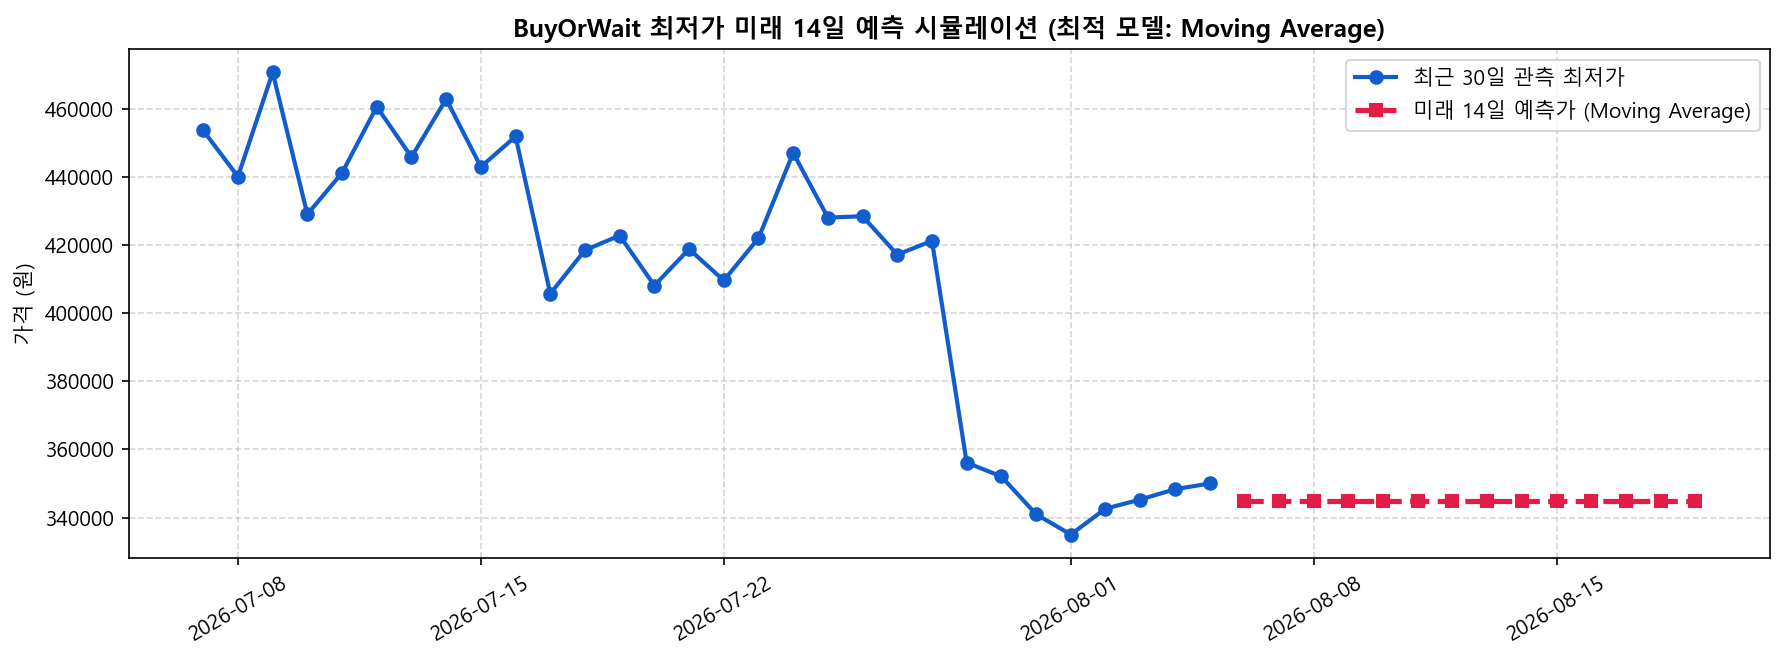


🏆 [프로젝트 최종 결론]
 1. 3-Fold Walk-Forward CV 최적 모델: 'Moving Average' (CV 평균 MAPE: 7.32%)
 2. 과거 14일 Hold-out 백테스팅 오차 : MAPE 6.37% (MAE 23,431원)
 ➔ 과거 Hold-out 평가에서 확인된 성능을 참고하여, 전체 관측 데이터를 재학습한 최종 선정 모델('Moving Average')로 향후 14일 가격 추세를 시뮬레이션하였습니다.


In [14]:
future_days = 14
last_date = df_daily.index.max()
future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=future_days, freq='D')

# 전체 데이터(Full History)로 CV 1위 최적 모델(best_model_name) 재학습 및 미래 14일 예측
full_train_input = df_daily[['price_final']].copy()
future_preds = train_and_predict_model(best_model_name, full_train_input, future_days)

# 최종 Forecast NaN 안전 검증
if np.isnan(future_preds).any():
    raise RuntimeError(f"최종 선정 모델 '{best_model_name}'의 미래 {future_days}일 예측에 실패했습니다.")

assert len(future_preds) == future_days, f"미래 예측 길이가 {future_days}일이 아닙니다!"

df_future_forecast = pd.DataFrame({
    '예측 날짜': future_dates.strftime('%Y-%m-%d'),
    '예측 최저가 (원)': [int(p) for p in future_preds]
})

print(f"🔮 [Step 16] 최종 최적 모델('{best_model_name}') 기반 향후 미래 14일 가격 예측 결과표 ({future_dates[0].strftime('%Y-%m-%d')} ~ {future_dates[-1].strftime('%Y-%m-%d')})")
display(df_future_forecast)

# 미래 예측 시각화 그래프
fig, ax = plt.subplots(figsize=(12, 4.5), dpi=150)
hist_recent = df_daily['price_final'].tail(30)

ax.plot(hist_recent.index, hist_recent.values, label='최근 30일 관측 최저가', color='#115DCE', linewidth=2, marker='o')
ax.plot(future_dates, future_preds, label=f'미래 14일 예측가 ({best_model_name})', color='#E11D48', linewidth=2.5, linestyle='--', marker='s')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.tick_params(axis='x', rotation=30)
ax.set_title(f"BuyOrWait 최저가 미래 14일 예측 시뮬레이션 (최적 모델: {best_model_name})", fontsize=12, fontweight='bold')
ax.set_ylabel('가격 (원)', fontsize=10)
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n🏆 [프로젝트 최종 결론]")
print(f" 1. 3-Fold Walk-Forward CV 최적 모델: '{best_model_name}' (CV 평균 MAPE: {best_cv_mape:.2f}%)")
print(f" 2. 과거 14일 Hold-out 백테스팅 오차 : MAPE {mape_prep:.2f}% (MAE {int(mae_prep):,}원)")
print(f" ➔ 과거 Hold-out 평가에서 확인된 성능을 참고하여, 전체 관측 데이터를 재학습한 최종 선정 모델('{best_model_name}')로 향후 14일 가격 추세를 시뮬레이션하였습니다.")

